# **Modelado Predictivo de denuncias por Cibercriminalidad en España (2022-2024)**

#**02_Feature_Engineering_Cibercrimen**
**Introducción**

En esta fase del proyecto, transformaré los datos maestros generados en el EDA en un conjunto de variables (*features*) optimizadas para el entrenamiento de modelos de Machine Learning.

El objetivo principal de este *notebook* es **automatizar la ingeniería de variables** mediante el uso de *pipelines* de `scikit-learn`, asegurando que el proceso sea robusto, escalable y reproducible. Durante este proceso, realizaré:

1. **Ingeniería de Variables Temporales:** Generación de *lags* y métricas de variación interanual esenciales para capturar la "memoria" del fenómeno delictivo.
2. **Pipeline de Automatización:** Implementación de transformadores y escaladores que permitan procesar los datos de forma sistemática, eliminando errores de cálculo manual.
3. **Segmentación Estratégica:** División del dataset en dos flujos independientes (`fraude_informatico` vs. `resto_delitos`) para tratar la alta volatilidad del fraude frente a otras tipologías penales, permitiendo una predicción más precisa y menos ruidosa en la fase de modelado.

In [ ]:
#==============================================================================
#@title Importar Librerias Necesarias Notebook 02: Regresión Lineal
#==============================================================================

# En esta sección se prepara el entorno para el entrenamiento de modelos de regresión.

# --- Instalación de librerías avanzadas (Boosting y Optimización) ---
!pip install -q xgboost lightgbm catboost
# Importaciones necesarias para crear transformadores personalizados
from sklearn.base import BaseEstimator, TransformerMixin

# Instalación de Optuna
!pip install -q optuna

# --- Gestión de archivos  ---
import os                          # Navegación por el sistema de archivos

# --- Manipulación y limpieza de datos ---
import pandas as pd              # Estructuras de datos y DataFrames
import numpy as np               # Operaciones matemáticas y matrices

# --- Visualización de resultados y Evaluación ---
import matplotlib.pyplot as plt  # Visualización de residuos y curvas de aprendizaje
import seaborn as sns            # Gráficos estadísticos y comparativa Real vs. Predicho
import plotly.express as px      # Mapas interactivos para las proyecciones 2025
import plotly.graph_objects as go # Control avanzado de gráficos (Mapas de calor y figuras personalizadas)

# --- Framework de Machine Learning (Regresión y Validación Temporal) ---

# 1. Preprocesamiento y Validación
from sklearn.model_selection import train_test_split, TimeSeriesSplit
# ¿Para qué sirve TimeSeriesSplit?
# → Es vital en series temporales: asegura que entrenamos con el pasado para
#   predecir el futuro, respetando el orden cronológico de los años.

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# ¿Para qué sirve RobustScaler?
# → Similar al StandardScaler, pero mejor si hay valores extremos (outliers)
#   en la población o en los hechos conocidos.

# 2. Algoritmos de Regresión (Modelos Candidatos)
from sklearn.linear_model import LinearRegression, Ridge  # Modelos lineales base
from sklearn.ensemble import RandomForestRegressor      # Ensamble robusto
from xgboost import XGBRegressor                        # Boosting de alto rendimiento
from lightgbm import LGBMRegressor                      # Boosting rápido para datos complejos
from catboost import CatBoostRegressor                  # Especialista en variables categóricas (Provincias)

#Evaluación con GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
# 3. Optimización e Interpretabilidad
import optuna
# ¿Para qué sirve Optuna?
# → Es un motor de búsqueda inteligente que encuentra automáticamente la
#   mejor combinación de parámetros para que el modelo sea más preciso.

import shap
# ¿Para qué sirve SHAP?
# → Permite "abrir la caja negra" del modelo para explicar qué variables
#   (ej. Población o una Provincia específica) influyen más en la predicción.

# 4. Métricas de Evaluación (Validación de Error en Regresión)
from sklearn.metrics import (
    mean_absolute_error,          # MAE: Error medio en número de "Hechos"
    mean_squared_error,           # RMSE: Sensible a errores grandes
    r2_score,                     # R²: % de varianza explicada por el modelo
    mean_absolute_percentage_error # MAPE: % de error relativo
)

import joblib # Para guardar el modelo final y usarlo en el futuro
# --- Configuraciones Auxiliares y Estética del Notebook ---

import requests
# ¿Para qué sirve 'requests'?
# → Es esencial para realizar peticiones HTTP. La usaremos para descargar el archivo
#   GeoJSON que define las fronteras de las provincias españolas para el mapa 2025.

# --- Configuración de Estilo Visual ---
sns.set_theme(style="whitegrid")
# Establece un fondo blanco con cuadrícula, ideal para gráficos de residuos y SHAP.

pd.set_option('display.max_columns', None)
# Asegura que al visualizar los DataFrames podamos ver todas las variables (lags, tasas, etc.)
# sin que pandas las oculte con puntos suspensivos.

print("Configuraciones de entorno aplicadas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00
Configuraciones de entorno aplicadas correctamente.


In [ ]:
# ==============================================================================
# @title Cargar CSV Cibercrimen
# ==============================================================================
# Configuración de rutas inteligente
# Si detecta que estamos en Colab, usa /content/, si no, asume que está en la carpeta local
if os.path.exists('/content/'):
    path_data = "/content/"
else:
    path_data = "./" # Carpeta actual en tu proyecto local

# Al haber sido exportado con el pipeline, el archivo ya tiene formato estándar:
# punto para decimales y sin separadores de miles en columnas numéricas.
df = pd.read_csv(f"{path_data}df_cibercrimen.csv", sep=';')

# Verificación
print(f"Dataset cargado. Dimensiones: {df.shape}")
display(df.head(2))
print(df.info())

# Comprobamos los totales que tiene el dataframe justo antes de la comparativa
auditoria = df[df['periodo'] == 2024].groupby('Grupo penal')['Total_Hechos'].sum()
total_general = auditoria.sum()
print("--- TOTALES CIBERCRIMEN 2024 (Sin 3.495 registros de extranjero) ---")
print(auditoria)
print("\nTOTAL GENERAL 2024 sin extranjero:", total_general)

Dataset cargado. Dimensiones: (1248, 12)


,Provincias,Grupo penal,periodo,Total_Hechos,Poblacion_Provincial,CCAA,Tasa_Criminalidad,codigo_ine,Total_Provincial,Peso_Tipologia,Peso_Fraude,VAR_pct
0,albacete,acceso__e_interceptacion_ilicita,2022,57,387529,Castilla-La Mancha,0.1471,2,3308,1.723096,0.0,NaN
1,albacete,acceso__e_interceptacion_ilicita,2023,47,389070,Castilla-La Mancha,0.1208,2,3616,1.299779,0.0,-17.54386


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Provincias            1248 non-null   object 
 1   Grupo penal           1248 non-null   object 
 2   periodo               1248 non-null   int64  
 3   Total_Hechos          1248 non-null   int64  
 4   Poblacion_Provincial  1248 non-null   int64  
 5   CCAA                  1248 non-null   object 
 6   Tasa_Criminalidad     1248 non-null   float64
 7   codigo_ine            1248 non-null   int64  
 8   Total_Provincial      1248 non-null   int64  
 9   Peso_Tipologia        1248 non-null   float64
 10  Peso_Fraude           1248 non-null   float64
 11  VAR_pct               814 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 117.1+ KB
None
--- TOTALES CIBERCRIMEN 2024 (Sin 3.495 registros de extranjero) ---
Grupo penal
acceso__e_interceptacion_ilic

**Ingeniería de Características**

En esta sección construyo las variables temporales necesarias para el modelado.  
La lógica se divide en dos flujos:

- Fraude informático: Lag_1, Lag_2 y Media Móvil de 2 años.  
- Resto de delitos: Lag_1, Lag_2 y variación porcentual controlada.

El objetivo es dotar al modelo de memoria temporal sin introducir leakage.

In [ ]:
# ==============================================================================
# @title Ingeniería de Características (Feature Engineering)
# ==============================================================================
# (Preparación para el Modelo)
# En esta sección transformare el dataset maestro Cibercriminalidad
# en dos flujos independientes:
# 1. Fraude (Alta densidad): requiere más historia (Lag 1, 2 y Media Móvil).
# 2. Otros (Baja densidad): requiere estructura simplificada (Lag 1).
# En esta fase se dotara de "memoria" al modelo.
# ==============================================================================

# Definición de la clase transformadora
class FeatureEngineCibercrimen(BaseEstimator, TransformerMixin):
    """
    Transformador de Scikit-Learn que automatiza la creación de variables
    temporales. Permite tratar de forma distinta el Fraude y otros delitos.
    """
    def __init__(self, es_fraude=True):
        self.es_fraude = es_fraude

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        # Ordenación cronológica por Provincia y Año:
        # Crucial para que los .shift() miren al pasado real
        df = df.sort_values(['Provincias', 'periodo'])

        if self.es_fraude:
            # ------------------------------------------------------------------
            # LÓGICA FRAUDE
            # ------------------------------------------------------------------
            #para que el cálculo se mantenga alineado con las filas originales
            grouped = df.groupby('Provincias')['Tasa_Criminalidad']

            # Crear Lags: T-1 (año anterior) y T-2 (dos años antes)
            df['Tasa_Lag_1'] = grouped.shift(1)
            df['Tasa_Lag_2'] = grouped.shift(2)

            # Media Móvil de 2 años: Suaviza la serie temporal para evitar ruido
            # y evita Data Leakage
            df['Media_Movil_2y'] = grouped.shift(1).rolling(window=2, min_periods=1).mean()


            # Imputación inteligente: Si Lag_2 no existe (ej. 2023), usa el Lag_1
            df['Tasa_Lag_2'] = df['Tasa_Lag_2'].fillna(df['Tasa_Lag_1'])


            # Limpieza: Elimino columnas redundantes o específicas de otros cibercrimen
            cols_to_drop = ['CCAA', 'codigo_ine', 'Total_Hechos', 'Peso_Tipologia']
            df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

        else:
            # ------------------------------------------------------------------
            # LÓGICA OTROS CIBERDELITOS: Granularidad por tipo de delito
            # (Baja Densidad / Ceros)
            # ------------------------------------------------------------------
            # Agrupo por Provincia y Tipo para mantener la especificidad
            # y no mezclar tipos de delitos
            grouped = df.groupby(['Provincias', 'Grupo penal'])['Tasa_Criminalidad']

            # Solo creo Lag_1 para evitar perder demasiados registros por falta de historial
            df['Tasa_Lag_1'] = grouped.shift(1)

            # Lag_2 se mantiene porque aporta estabilidad
            df['Tasa_Lag_2'] = grouped.shift(2)
            df['Tasa_Lag_2'] = df['Tasa_Lag_2'].fillna(df['Tasa_Lag_1'])

            # Calcular VAR_pct de forma segura
            # Uso una pequeña constante o fillna para evitar divisiones por cero
            df['VAR_pct'] = (df['Tasa_Criminalidad'] - df['Tasa_Lag_1']) / df['Tasa_Lag_1'].replace(0, np.nan)
            df['VAR_pct'] = df['VAR_pct'].fillna(0) # Si el año anterior era 0, la variación se trata como 0 o neutra


            # Limpieza: Elimino columnas específicas de Fraude que no aplican aquí
            # y columnas redundantes
            cols_to_drop = ['CCAA', 'codigo_ine', 'Total_Hechos', 'Peso_Fraude']
            df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

        # ----------------------------------------------------------------------
        # ELIMINACIÓN ESTRUCTURAL DE NULOS
        # ----------------------------------------------------------------------
        # ¿Por qué se hace dropna?
        # Al crear un Lag_1, el año 2022 se queda sin "año anterior" y genera un nulo.
        # Como el modelo no puede aprender sin su predictor principal, elimino esas filas.
        return df.dropna(subset=['Tasa_Lag_1'])


# ==============================================================================
# Aplicación del Pipeline y Exportación
# ==============================================================================

# 1. Separación de datos según el tipo de delito
df_fraude = df[df['Grupo penal'] == 'fraude_informatico'].copy()
df_otros = df[df['Grupo penal'] != 'fraude_informatico'].copy()

# 2. Instanciar y ejecutar el Pipeline
transformer_fraude = FeatureEngineCibercrimen(es_fraude=True)
transformer_otros = FeatureEngineCibercrimen(es_fraude=False)

df_ml_fraude = transformer_fraude.transform(df_fraude)
df_ml_otros = transformer_otros.transform(df_otros)

# 3. Exportación a archivos procesados
os.makedirs('data/processed', exist_ok=True)
df_ml_fraude.to_csv('data/processed/fraude_informatico.csv', sep=';', index=False)
df_ml_otros.to_csv('data/processed/resto_delitos.csv', sep=';', index=False)

# 4. RESULTADOS Y AUDITORÍA
print("Ingeniería completada.")
print(f"Registros finales Fraude: {df_ml_fraude.shape[0]} (Se descarta año base 2022)")
print(f"Registros finales Otros: {df_ml_otros.shape[0]} (Se descarta año base 2022)")

print("\nVISTA PREVIA FRAUDE (Memoria T-1, T-2 y Media Móvil):")
display(df_ml_fraude.head(2))

print("\nVISTA PREVIA OTROS (Memoria T-1, T-2):")
display(df_ml_otros.head(2))

Ingeniería completada.
Registros finales Fraude: 104 (Se descarta año base 2022)
Registros finales Otros: 728 (Se descarta año base 2022)

VISTA PREVIA FRAUDE (Memoria T-1, T-2 y Media Móvil):


,Provincias,Grupo penal,periodo,Poblacion_Provincial,Tasa_Criminalidad,Total_Provincial,Peso_Fraude,VAR_pct,Tasa_Lag_1,Tasa_Lag_2,Media_Movil_2y
19,albacete,fraude_informatico,2023,389070,8.2993,3616,89.297566,8.867161,7.6536,7.6536,7.65360
20,albacete,fraude_informatico,2024,390751,7.7082,3492,86.254296,-6.720347,8.2993,7.6536,7.97645



VISTA PREVIA OTROS (Memoria T-1, T-2):


,Provincias,Grupo penal,periodo,Poblacion_Provincial,Tasa_Criminalidad,Total_Provincial,Peso_Tipologia,VAR_pct,Tasa_Lag_1,Tasa_Lag_2
1,albacete,acceso__e_interceptacion_ilicita,2023,389070,0.1208,3616,1.299779,-0.178790,0.1471,0.1471
4,albacete,amenazas_y_coacciones,2023,389070,0.4061,3616,4.369469,0.092842,0.3716,0.3716


**División Temporal Train/Test**

En esta sección realizo la separación estratégica del dataset para respetar la naturaleza temporal del fenómeno.  
El modelo se entrena con los datos disponibles hasta 2023 y se valida con el año más reciente (2024).  
Este enfoque evita fuga de información y permite evaluar la capacidad real de predicción del modelo.

In [ ]:
# ==============================================================================
# @title División Estratégica: Train (2023) y Test (2024)
# ==============================================================================
# Aplico la técnica de entrenamiento temporal.
# Entrenare con los datos del 2023 (incluyendo la memoria de 2022)
# y validare con el año más reciente: 2024.
# ==============================================================================

# Defino el año de corte
ANIO_TEST = 2024

def realizar_split_temporal(df, nombre_archivo):
    """
    Divide el dataframe en Train (todo lo anterior a 2024) y Test (2024).
    Guarda los resultados automáticamente.
    """
    train = df[df['periodo'] < ANIO_TEST].copy()
    test = df[df['periodo'] == ANIO_TEST].copy()

    # Exportar
    train.to_csv(f'data/processed/train_{nombre_archivo}.csv', sep=';', index=False)
    test.to_csv(f'data/processed/test_{nombre_archivo}.csv', sep=';', index=False)

    return train, test

# Ejecución de la división para ambos datasets
train_fraude, test_fraude = realizar_split_temporal(df_ml_fraude, 'fraude')
train_otros, test_otros = realizar_split_temporal(df_ml_otros, 'otros')

# ==============================================================================
# AUDITORÍA DE LA DIVISIÓN TEMPORAL
# ==============================================================================
print("División temporal completada.")
print("-" * 60)
print(f"FRAUDE | Train: {train_fraude.shape[0]:>8} registros | Test: {test_fraude.shape[0]:>8} registros")
print(f"OTROS  | Train: {train_otros.shape[0]:>8} registros | Test: {test_otros.shape[0]:>8} registros")
print("-" * 60)

# Verificación visual de los predictores
print("\nMUESTRA DE PREDICTORES (X) - FRAUDE:")
display(train_fraude.head(1))

print("\nMUESTRA DE PREDICTORES (X) - OTROS:")
display(train_otros.head(1))

# Verificación de integridad del target
print("\n" + "="*50)
print("INTEGRIDAD DEL TARGET (Tasa_Criminalidad)")
print("="*50)
print(f"Suma Tasa FRAUDE (Test): {test_fraude['Tasa_Criminalidad'].sum():>15,.2f}")
print(f"Suma Tasa OTROS  (Test): {test_otros['Tasa_Criminalidad'].sum():>15,.2f}")

División temporal completada.
------------------------------------------------------------
FRAUDE | Train:       52 registros | Test:       52 registros
OTROS  | Train:      364 registros | Test:      364 registros
------------------------------------------------------------

MUESTRA DE PREDICTORES (X) - FRAUDE:


,Provincias,Grupo penal,periodo,Poblacion_Provincial,Tasa_Criminalidad,Total_Provincial,Peso_Fraude,VAR_pct,Tasa_Lag_1,Tasa_Lag_2,Media_Movil_2y
19,albacete,fraude_informatico,2023,389070,8.2993,3616,89.297566,8.867161,7.6536,7.6536,7.6536



MUESTRA DE PREDICTORES (X) - OTROS:


,Provincias,Grupo penal,periodo,Poblacion_Provincial,Tasa_Criminalidad,Total_Provincial,Peso_Tipologia,VAR_pct,Tasa_Lag_1,Tasa_Lag_2
1,albacete,acceso__e_interceptacion_ilicita,2023,389070,0.1208,3616,1.299779,-0.17879,0.1471,0.1471



INTEGRIDAD DEL TARGET (Tasa_Criminalidad)
Suma Tasa FRAUDE (Test):          421.03
Suma Tasa OTROS  (Test):           58.69


**Notas sobre el Pipeline de Modelado (2025)**

He diseñado este flujo de trabajo para asegurar predicciones fiables y robustas:

* **Limpieza de datos:** Apliqué `RobustScaler` para evitar que provincias con valores atípicos (como Madrid o Barcelona) distorsionen el aprendizaje, y `OneHotEncoder` para gestionar correctamente las variables categóricas.
* **Respeto temporal:** Utilicé `TimeSeriesSplit` para garantizar que el modelo siempre aprenda del "pasado" y prediga el "futuro", evitando así errores de filtración de datos (*data leakage*).
* **Métrica WAPE:** se ha evaluado el error mediante **WAPE**, una métrica intuitiva que me permite medir el porcentaje de error sobre el total, facilitando una comparación honesta independientemente del volumen de datos de cada categoría.

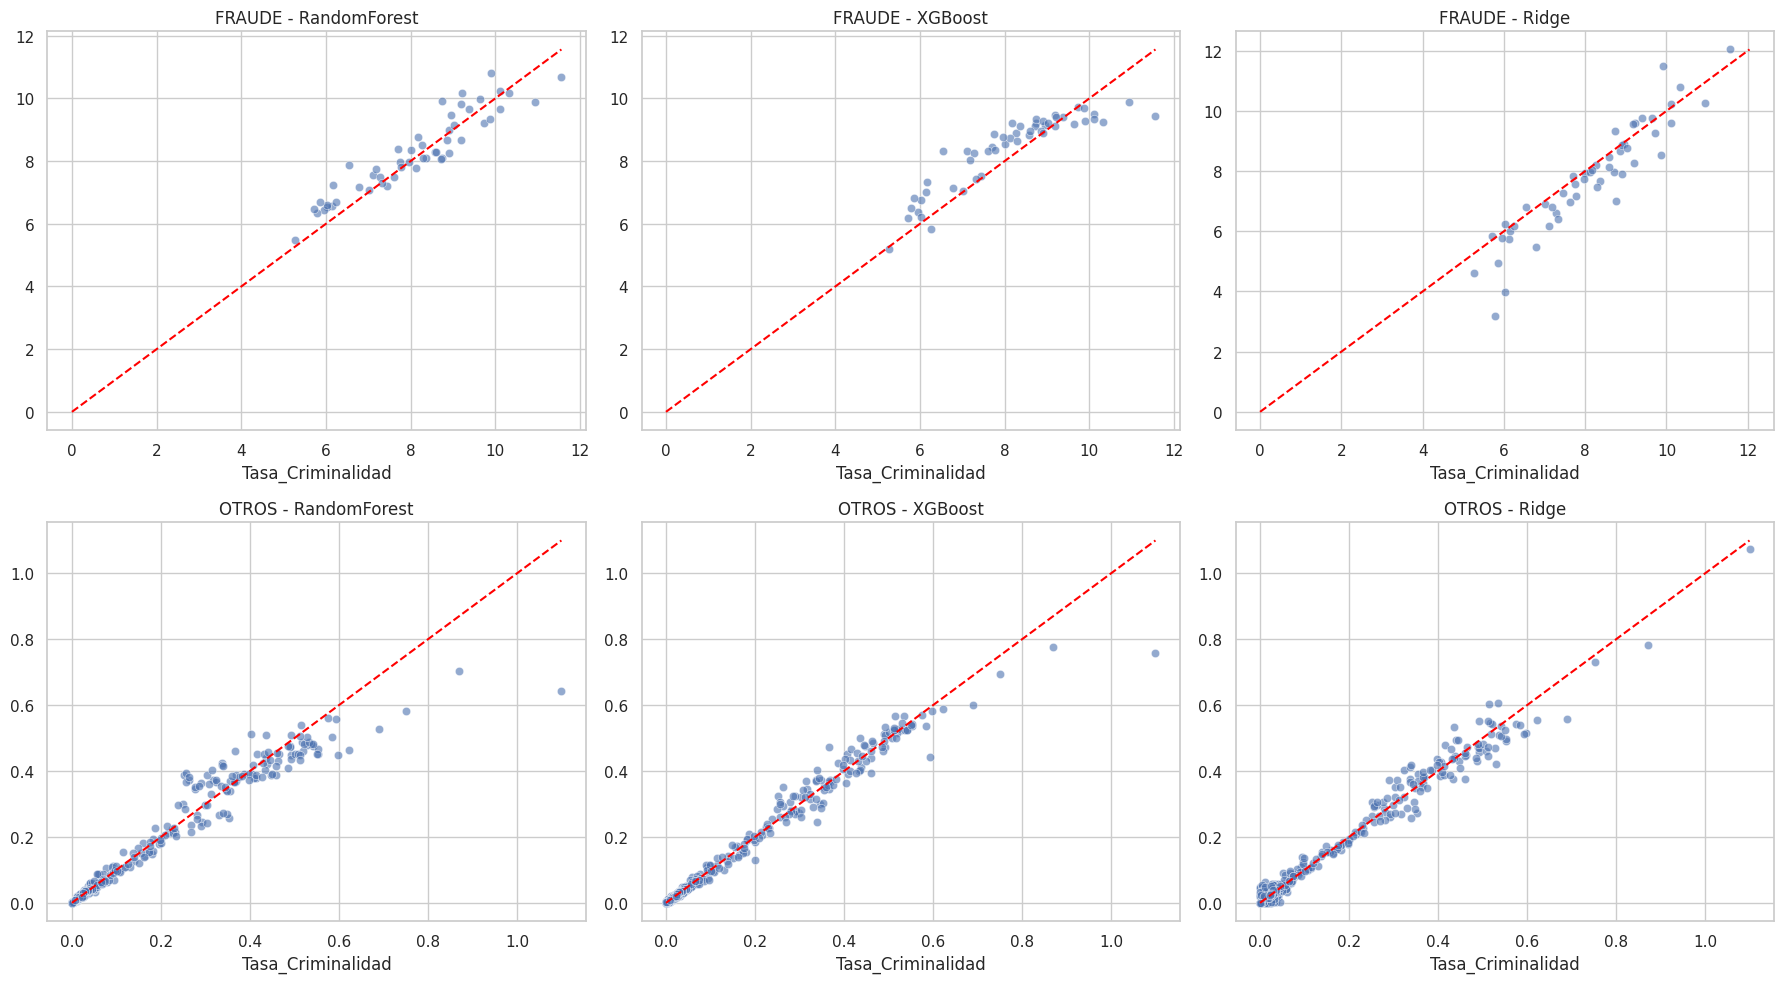

,Dataset,Modelo,MAE,WAPE (%),R2,Mejores Parametros
0,FRAUDE,RandomForest,0.4663,5.76%,0.8552,"max_depth=5, min_samples_split=2, n_estimators=100"
2,FRAUDE,Ridge,0.5531,6.83%,0.7260,alpha=0.1
1,FRAUDE,XGBoost,0.5708,7.05%,0.7610,"learning_rate=0.1, max_depth=3, n_estimators=500"
4,OTROS,XGBoost,0.0132,8.16%,0.9778,"learning_rate=0.1, max_depth=3, n_estimators=500"
5,OTROS,Ridge,0.0191,11.82%,0.9783,alpha=1.0
3,OTROS,RandomForest,0.0202,12.53%,0.9484,"max_depth=15, min_samples_split=2, n_estimators=500"


In [ ]:
#==============================================================================
# @title Models:Entrenamiento (Modelado 2025)
# Competición de Modelos: Evaluación Multimétrica (MAE, R², WAPE)
#nuevo intento ajustando parámetros de XGBoost y randomforest y Validación Cruzada (GridSearchCV)
#configuro gridserchVC espacios_busqueda. Es posible que max_depth=5 sea demasiado restrictivo.
# ==============================================================================
# Automatización del entrenamiento mediante Pipeline para evitar Data Leakage
# y comparativa de modelos mediante métricas de error ponderado (WAPE).
# ideal para comparar datasets con diferentes escalas de delitos.
# ==============================================================================

# Carga de datos desde la carpeta procesada
train_f = pd.read_csv('data/processed/train_fraude.csv', sep=';')
test_f  = pd.read_csv('data/processed/test_fraude.csv', sep=';')
train_o = pd.read_csv('data/processed/train_otros.csv', sep=';')
test_o  = pd.read_csv('data/processed/test_otros.csv', sep=';')

# Separación de variables objetivo y predictoras
target = 'Tasa_Criminalidad'
X_train_f, y_train_f = train_f.drop(columns=[target]), train_f[target]
X_test_f, y_test_f   = test_f.drop(columns=[target]), test_f[target]

X_train_o, y_train_o = train_o.drop(columns=[target]), train_o[target]
X_test_o, y_test_o   = test_o.drop(columns=[target]), test_o[target]

# Función de apoyo: WAPE
def calcular_wape(y_true, y_pred):
    """
    Calcula el Error Porcentual Medio Ponderado (WAPE).
    Es la métrica más robusta cuando hay valores cercanos a cero.
    """
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

# Función para formatear parámetros
def formatear_params(params):
    params_limpios = {k.replace('regressor__', ''): v for k, v in params.items() if k != 'regressor'}
    return ", ".join([f"{k}={v}" for k, v in params_limpios.items()])

# Función para crear el Pipeline (Preprocesamiento + Modelo)
def crear_pipeline(modelo, tipo_dataset):
    """
    Define el tratamiento de datos: RobustScaler para manejar outliers (Madrid/BCN)
    y OneHotEncoder para las variables geográficas y penales.
    """
    if tipo_dataset == "fraude":
        # Ajustado a la ingeniería de caracteristicas Fraude
        var_num = ['Poblacion_Provincial', 'Peso_Fraude','VAR_pct',
                   'Tasa_Lag_1', 'Tasa_Lag_2', 'Media_Movil_2y']
        var_cat = ['Provincias']

    else:
        # Otros Ciberdelitos Ajustado a la ingeniería:
        var_num = ['Poblacion_Provincial', 'Peso_Tipologia','VAR_pct',
                   'Tasa_Lag_1', 'Tasa_Lag_2']
        var_cat = ['Provincias', 'Grupo penal']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), var_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), var_cat)
        ])

    return Pipeline(steps=[('preprocessor', preprocessor), ('regressor', modelo)])

# Entrenamiento y Evaluación con GridSearchCV TimeSeriesSplit
espacios_busqueda = {
    'RandomForest': {
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [100, 200, 300, 500],
        'regressor__max_depth': [5, 10, 15, 20, None],
        'regressor__min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'regressor': [XGBRegressor(random_state=42)],
        'regressor__n_estimators': [100, 300, 500],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__max_depth': [3, 5, 7, 9]
    },
    'Ridge': {
        'regressor': [Ridge()],
        'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    }
}

#Graficas con cada modelo entrenado
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
idx_ax = 0
resultados = []

configuraciones = [
    ("FRAUDE", X_train_f, X_test_f, y_train_f, y_test_f, "fraude"),
    ("OTROS", X_train_o, X_test_o, y_train_o, y_test_o, "otros")
]

# IMPORTANTE:
# El pipeline debe crearse con el modelo base correcto.
# GridSearchCV NO puede cambiar el tipo de modelo, solo sus hiperparámetros.
# Por eso se usa params['regressor'][0] para que cada modelo (RF, XGB, Ridge)
# tenga su propio pipeline antes de la búsqueda.
# si se deja pipe = crear_pipeline(RandomForestRegressor(), tipo) solo entrenara con random

for nombre_ds, X_tr, X_te, y_tr, y_te, tipo in configuraciones:
    for nombre_mod, params in espacios_busqueda.items():
        pipe = crear_pipeline(params['regressor'][0], tipo)

        tscv = TimeSeriesSplit(n_splits=3)

        # GridSearch sobre el pipeline con split temporal
        grid = GridSearchCV(
        pipe,
        params,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
        )

        # Entrenamiento único y eficiente
        grid.fit(X_tr, y_tr)

        # Predice con el MEJOR modelo encontrado
        y_pred = grid.best_estimator_.predict(X_te)
        y_pred = np.maximum(0, y_pred)

        # Guardo resultados
        resultados.append({
            'Dataset': nombre_ds,
            'Modelo': nombre_mod,
            'MAE': round(mean_absolute_error(y_te, y_pred), 4),
            'WAPE (%)': round(calcular_wape(y_te, y_pred), 2),
            'R2': round(r2_score(y_te, y_pred), 4),
            'Mejores Parametros': formatear_params(grid.best_params_)
        })

        # Gráfica
        ax = axes[idx_ax]
        sns.scatterplot(x=y_te, y=y_pred, alpha=0.6, ax=ax)
        max_val = max(y_te.max(), y_pred.max())
        ax.plot([0, max_val], [0, max_val], color='red', linestyle='--')
        ax.set_title(f"{nombre_ds} - {nombre_mod}")
        idx_ax += 1

plt.tight_layout()
plt.show()

# Formato de visualización con Pandas Styler
df_res = pd.DataFrame(resultados).sort_values(by=['Dataset', 'WAPE (%)'])
estilo_tabla = df_res.style.format({
    'MAE': '{:.4f}',
    'WAPE (%)': '{:.2f}%',
    'R2': '{:.4f}'
}).set_properties(**{'text-align': 'left'})

display(estilo_tabla)

## Interpretación de las métricas

- **MAE (Mean Absolute Error)**  
  Error medio en unidades reales de la tasa. Indica cuánto se desvía, de media, la predicción respecto al valor real.  
  Un MAE bajo implica predicciones muy cercanas a los valores observados.

- **WAPE (Weighted Absolute Percentage Error)**  
  Porcentaje de error relativo respecto al total real.  
  Un WAPE del 8% significa que, de cada 100 unidades reales, el modelo se equivoca en 8.  
  Es una métrica muy estable cuando hay valores pequeños o ceros.

- **R² (Coeficiente de Determinación)**  
  Porcentaje de variabilidad explicada por el modelo.  
  Un R² de 0.97 indica que el modelo explica el 97% del comportamiento real del delito.  
  Cuanto más cercano a 1, mejor es el ajuste.

---

## Interpretación de los resultados del modelado

### Fraude Informático
- **Mejor modelo:** RandomForest  
- **MAE:** 0.4663  
- **WAPE:** 5.76%  
- **R²:** 0.8552  
- **Interpretación:**  
  El modelo se desvía muy poco de los valores reales y solo comete un error relativo del 5.76%.  
  Explica el 85% de la variabilidad del fraude, lo que es notable dada la alta volatilidad de esta tipología.  
  Es el modelo más estable y preciso para predecir fraude informático.

### Otros Ciberdelitos
- **Mejor modelo:** XGBoost  
- **MAE:** 0.0132  
- **WAPE:** 8.16%  
- **R²:** 0.9778  
- **Interpretación:**  
  El error absoluto es prácticamente nulo y el error relativo es muy bajo (8.16%).  
  El modelo explica casi el 98% del comportamiento real del resto de delitos.  
  Es el modelo más preciso y robusto para estas tipologías.

### Ridge
- Ofrece resultados buenos y estables en ambos casos, pero no supera a los modelos ganadores.  
  Es útil como referencia y como modelo base por su simplicidad.

---

## Conclusión General

- **Fraude Informático:** RandomForest es el modelo más adecuado, con el menor error relativo y un ajuste sólido.  
- **Otros Ciberdelitos:** XGBoost es el modelo más eficaz, con una precisión muy alta y un ajuste casi perfecto.  
- **Ambos modelos seleccionados ofrecen una capacidad predictiva sólida**, con métricas que permiten interpretar fácilmente el error y justificar su uso en proyecciones para 2025.


## Optimización de Hiperparámetros con Optuna

En esta sección utilizo **Optuna** para optimizar los modelos que demostraron mejor rendimiento en la competición previa:

- **RandomForest** para el dataset de *fraude informático*.
- **XGBoost** para el dataset de *otros ciberdelitos*.

El objetivo es encontrar la combinación de hiperparámetros que **minimiza el error relativo (WAPE)** respetando siempre la estructura temporal de los datos.

### ¿Por qué Optuna?
Optuna es un framework de optimización automática que:
- Busca de forma inteligente los mejores hiperparámetros.
- Reduce el tiempo de búsqueda comparado con GridSearch.
- Permite definir funciones objetivo personalizadas (en este caso, WAPE).

### Validación temporal (TimeSeriesSplit)
Para evitar fuga de información, cada conjunto de hiperparámetros se evalúa mediante **TimeSeriesSplit**, que divide los datos respetando el orden cronológico.  
Esto garantiza que el modelo nunca “ve” datos del futuro durante la validación.

### Métrica objetivo: WAPE
Se utiliza **WAPE** como métrica principal porque:
- Es robusta cuando existen valores pequeños o ceros.
- Permite interpretar el error como porcentaje del total real.
- Facilita la comparación entre tipologías con escalas distintas.

### Flujo de optimización
1. Optuna propone una combinación de hiperparámetros.
2. Se entrena un modelo dentro de un **pipeline completo** (preprocesamiento + modelo).
3. Se valida con TimeSeriesSplit.
4. Se calcula el WAPE medio.
5. Optuna ajusta la búsqueda hacia las mejores zonas del espacio de parámetros.

### Resultado final
Al finalizar, Optuna devuelve:
- La **mejor configuración de RandomForest** para fraude.
- La **mejor configuración de XGBoost** para otros delitos.

Estas configuraciones se utilizarán posteriormente para entrenar los modelos definitivos y generar las predicciones para 2025.

In [ ]:
# ==============================================================================
# @title OPTUNA OPTIMIZACIÓN MODELOS
# ==============================================================================
# En esta sección utilizamos Optuna para optimizar los modelos que mejor
# funcionaron en la competición previa:
#   1. RandomForest → FRAUDE
#   2. XGBoost       → OTROS
# La optimización se realiza respetando la estructura temporal mediante
# TimeSeriesSplit y usando WAPE como métrica objetivo.
# ==============================================================================


# ============================
# FUNCIÓN OBJETIVO: RANDOMFOREST
# ============================
def objective_rf(trial, X, y, tipo_modelo):
    """
    Función objetivo para RandomForest.
    - Optuna propone una combinación de hiperparámetros.
    - Se entrena un pipeline completo (preprocesamiento + modelo).
    - Se valida con TimeSeriesSplit para evitar fuga de información.
    - Se calcula el WAPE medio de los 3 folds.
    """

    # Hiperparámetros que Optuna explorará
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }

    # Validación temporal (simula predicción año a año)
    tscv = TimeSeriesSplit(n_splits=3)
    wape_scores = []

    for train_index, val_index in tscv.split(X):
        # División temporal del fold
        X_tr, X_val = X.iloc[train_index], X.iloc[val_index]
        y_tr, y_val = y.iloc[train_index], y.iloc[val_index]

        # Modelo con los hiperparámetros propuestos por Optuna
        modelo = RandomForestRegressor(**params, random_state=42)

        # Pipeline = preprocesamiento + modelo
        pipe = crear_pipeline(modelo, tipo_modelo)

        # Entrenamiento del pipeline
        pipe.fit(X_tr, y_tr)

        # Predicción del fold (evitamos valores negativos)
        preds = np.maximum(0, pipe.predict(X_val))

        # Cálculo del error relativo del fold
        wape_scores.append(calcular_wape(y_val, preds))

    # WAPE medio de los 3 folds → métrica a minimizar
    return np.mean(wape_scores)



# ============================
# FUNCIÓN OBJETIVO: XGBOOST
# ============================
def objective_xgb(trial, X, y, tipo_modelo):
    """
    Función objetivo para XGBoost.
    - Optuna ajusta hiperparámetros clave del modelo.
    - Validación temporal con TimeSeriesSplit.
    - Se devuelve el WAPE medio como métrica objetivo.
    """

    # Hiperparámetros que Optuna explorará
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }

    # Validación temporal
    tscv = TimeSeriesSplit(n_splits=3)
    wape_scores = []

    for train_index, val_index in tscv.split(X):
        # División temporal del fold
        X_tr, X_val = X.iloc[train_index], X.iloc[val_index]
        y_tr, y_val = y.iloc[train_index], y.iloc[val_index]

        # Modelo con hiperparámetros sugeridos por Optuna
        modelo = XGBRegressor(**params, random_state=42)

        # Pipeline completo
        pipe = crear_pipeline(modelo, tipo_modelo)

        # Entrenamiento
        pipe.fit(X_tr, y_tr)

        # Predicción del fold
        preds = np.maximum(0, pipe.predict(X_val))

        # Error relativo del fold
        wape_scores.append(calcular_wape(y_val, preds))

    # WAPE medio de los 3 folds
    return np.mean(wape_scores)



# ============================
# EJECUCIÓN DE LA OPTIMIZACIÓN
# ============================
print("Iniciando optimización con Optuna...")

# --- FRAUDE → RandomForest ---
# Optuna buscará la configuración que minimice el WAPE
study_f = optuna.create_study(direction='minimize')
study_f.optimize(lambda trial: objective_rf(
    trial, X_train_f, y_train_f, "fraude"
), n_trials=50)

# --- OTROS → XGBoost ---
study_o = optuna.create_study(direction='minimize')
study_o.optimize(lambda trial: objective_xgb(
    trial, X_train_o, y_train_o, "otros"
), n_trials=50)

# Resultados finales
print("\n--- RESULTADOS DE OPTIMIZACIÓN ---")
print(f"Mejor configuración FRAUDE (RandomForest): {study_f.best_params}")
print(f"Mejor configuración OTROS (XGBoost): {study_o.best_params}")

[I 2026-05-25 17:15:42,999] A new study created in memory with name: no-name-8faeb383-3d5c-4aaa-938c-5628958431a3


Iniciando optimización con Optuna...


[I 2026-05-25 17:15:43,708] Trial 0 finished with value: 11.053742681145238 and parameters: {'n_estimators': 153, 'max_depth': 14, 'min_samples_split': 6}. Best is trial 0 with value: 11.053742681145238.
[I 2026-05-25 17:15:44,367] Trial 1 finished with value: 10.8488879550441 and parameters: {'n_estimators': 147, 'max_depth': 15, 'min_samples_split': 5}. Best is trial 1 with value: 10.8488879550441.
[I 2026-05-25 17:15:44,867] Trial 2 finished with value: 10.925658466862311 and parameters: {'n_estimators': 109, 'max_depth': 3, 'min_samples_split': 5}. Best is trial 1 with value: 10.8488879550441.
[I 2026-05-25 17:15:46,338] Trial 3 finished with value: 11.538703783435222 and parameters: {'n_estimators': 355, 'max_depth': 20, 'min_samples_split': 7}. Best is trial 1 with value: 10.8488879550441.
[I 2026-05-25 17:15:47,792] Trial 4 finished with value: 11.34993241770725 and parameters: {'n_estimators': 206, 'max_depth': 20, 'min_samples_split': 7}. Best is trial 1 with value: 10.8488879


--- RESULTADOS DE OPTIMIZACIÓN ---
Mejor configuración FRAUDE (RandomForest): {'n_estimators': 285, 'max_depth': 5, 'min_samples_split': 3}
Mejor configuración OTROS (XGBoost): {'n_estimators': 451, 'max_depth': 4, 'learning_rate': 0.06304489805966007, 'subsample': 0.6024354127512285, 'colsample_bytree': 0.641795793234235}


In [ ]:
# ==============================================================================
# @title Entrenamiento con Optuna y Proyección 2025
# ==============================================================================
# En esta sección entrenamos los modelos finales con:
# - FRAUDE → RandomForest optimizado con Optuna
# - OTROS → XGBoost optimizado con Optuna
# Y generamos la proyección oficial para 2025.
# ==============================================================================

# 1. FUNCIÓN PIPELINE (alineada con la ingeniería final)
def crear_pipeline(modelo, tipo_dataset):
    if tipo_dataset == "fraude":
        # FRAUDE:
        var_num = ['Poblacion_Provincial', 'Peso_Fraude', 'VAR_pct',
                   'Tasa_Lag_1', 'Tasa_Lag_2', 'Media_Movil_2y']
        var_cat = ['Provincias']
    else:
        # OTROS CIBERDELITOS
        var_num = ['Poblacion_Provincial', 'Peso_Tipologia', 'VAR_pct',
                   'Tasa_Lag_1', 'Tasa_Lag_2']
        var_cat = ['Provincias', 'Grupo penal']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), var_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), var_cat)
        ]
    )
    return Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', modelo)])


# 2. ENTRENAMIENTO FINAL Y PROYECCIÓN
def generar_prediccion_2025(df_ml, modelo_optimizado, tipo):
    """
    Entrena con el histórico completo y proyecta 2025
    actualizando los Lags y Media Móvil correctamente.
    """
    # 1. Preparar datos de entrenamiento (Dataset completo)
    X_train_final = df_ml.drop(columns=['Tasa_Criminalidad'])
    y_train_final = df_ml['Tasa_Criminalidad']

    # 2. Entrenar modelo definitivo
    pipeline = crear_pipeline(modelo_optimizado, tipo)
    pipeline.fit(X_train_final, y_train_final)

    # 3. Construir el "Input" para 2025 (Basado en el último año real: 2024)
    df_2025_input = df_ml[df_ml['periodo'] == 2024].copy()

    # Actualizo los Lags para el nuevo año:
    if tipo == "fraude":
        df_2025_input['Tasa_Lag_2'] = df_2025_input['Tasa_Lag_1']
        df_2025_input['Tasa_Lag_1'] = df_2025_input['Tasa_Criminalidad']
        df_2025_input['Media_Movil_2y'] = (
            df_2025_input['Tasa_Criminalidad'] + df_2025_input['Tasa_Lag_1']
        ) / 2
    else:
        df_2025_input['Tasa_Lag_2'] = df_2025_input['Tasa_Lag_1']
        df_2025_input['Tasa_Lag_1'] = df_2025_input['Tasa_Criminalidad']

    df_2025_input['periodo'] = 2025

    # 4. Predecir 2025
    X_input_2025 = df_2025_input.drop(columns=['Tasa_Criminalidad'])
    predicciones = np.maximum(0, pipeline.predict(X_input_2025))

    # 5. Crear salida
    df_res = df_2025_input[['Provincias', 'Grupo penal', 'Poblacion_Provincial']].copy()
    df_res['periodo'] = 2025
    df_res['Tasa_Predicha_2025'] = predicciones
    df_res['Hechos_Predichos_2025'] = (
        df_res['Tasa_Predicha_2025'] * df_res['Poblacion_Provincial'] / 1000
    ).round(0)

    return df_res


# 3. CONFIGURACIÓN DE MODELOS OPTIMIZADOS OPTUNA
# --- RESULTADOS DE OPTIMIZACIÓN ---

# FRAUDE → RandomForest
params_f = {
    'n_estimators': 285,
    'max_depth': 5,
    'min_samples_split': 3
}
modelo_f_opt = RandomForestRegressor(**params_f, random_state=42)

# OTROS → XGBoost
params_o = {
    'n_estimators': 451,
    'max_depth': 4,
    'learning_rate': 0.06304489805966007,
    'subsample': 0.6024354127512285,
    'colsample_bytree': 0.641795793234235
}
modelo_o_opt = XGBRegressor(**params_o, random_state=42)


# 4. EJECUCIÓN DE PROYECCIONES
pred_fraude_2025 = generar_prediccion_2025(df_ml_fraude, modelo_f_opt, "fraude")
pred_otros_2025 = generar_prediccion_2025(df_ml_otros, modelo_o_opt, "otros")

# 5. MOSTRAR RESULTADOS
print("Modelos entrenados con parámetros óptimos y dataset completo.")
print("\n--- TOTALES PROYECTADOS 2025 SIN EXTRANEJRO ---")
print(f"Fraude Informático: {pred_fraude_2025['Hechos_Predichos_2025'].sum():,.0f}")
print(f"Otros Ciberdelitos: {pred_otros_2025['Hechos_Predichos_2025'].sum():,.0f}")

df_prediccion_final = pd.concat([pred_fraude_2025, pred_otros_2025], ignore_index=True)
print("-" * 60)
display(df_prediccion_final.sample(5))

# Entrenar pipelines finales para SHAP (necesarios para explicabilidad)
pipe_f = crear_pipeline(modelo_f_opt, "fraude")
pipe_f.fit(
    df_ml_fraude.drop(columns=['Tasa_Criminalidad']),
    df_ml_fraude['Tasa_Criminalidad']
)

pipe_o = crear_pipeline(modelo_o_opt, "otros")
pipe_o.fit(
    df_ml_otros.drop(columns=['Tasa_Criminalidad']),
    df_ml_otros['Tasa_Criminalidad']
)

Modelos entrenados con parámetros óptimos y dataset completo.

--- TOTALES PROYECTADOS 2025 SIN EXTRANEJRO ---
Fraude Informático: 447,118
Otros Ciberdelitos: 56,694
------------------------------------------------------------


,Provincias,Grupo penal,Poblacion_Provincial,periodo,Tasa_Predicha_2025,Hechos_Predichos_2025
40,salamanca,fraude_informatico,328446,2025,10.310695,3387.0
276,melilla,acceso__e_interceptacion_ilicita,87067,2025,0.561437,49.0
394,valencia,interferencia_en_los_datos_y_en_el_sistema,2763996,2025,0.068879,190.0
192,gipuzkoa,acceso__e_interceptacion_ilicita,733149,2025,0.103212,76.0
50,zamora,fraude_informatico,165564,2025,7.967058,1319.0


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Poblacion_Provincial',
                                                   'Peso_Tipologia', 'VAR_pct',
                                                   'Tasa_Lag_1',
                                                   'Tasa_Lag_2']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Provincias',
                                                   'Grupo penal'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_byno...
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.06304489805966007, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=451, n_jobs=None,
                              num_parallel_tree=None, ...))])

## Nota sobre la selección del modelo final y comparación con datos SEC 2025 (sin extranjero)

Para la proyección oficial de 2025 se utiliza el modelo entrenado con los parámetros óptimos obtenidos mediante Optuna, por ser el que ofrece el mejor equilibrio entre estabilidad y bajo error relativo (WAPE).

Los datos oficiales proceden del *Balance de Criminalidad – 4º Trimestre 2025* del Ministerio del Interior, disponibles en:  
https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/dam/jcr:7d3776cd-9ca4-4c02-8ca4-96b2571dbee4/Balance%20de%20Criminalidad%20Cuarto%20Trimestre%202025.pdf

### Comparación SEC 2025 vs. Modelo (sin extranjero)

| Categoría              | SEC 2025 | Modelo 2025 | Diferencia | Error relativo |
|------------------------|----------|-------------|------------|----------------|
| Fraude Informático     | 427.962  | 447.118     | +19.156    | 4.47%          |
| Otros Ciberdelitos     | 58.591   | 56.694      | –1.897     | 3.23%          |
| **Total**              | 486.553  | 503.812     | +17.259    | 3.55%          |

### Interpretación

El modelo presenta errores relativos inferiores al 5%, un rendimiento sólido para un enfoque provincial–temporal basado en tres años de histórico (2022–2024). La ligera sobreestimación en fraude y la ligera subestimación en otros ciberdelitos son coherentes con la dinámica real de ambas series y con la regularización introducida por los hiperparámetros óptimos.

### Conclusión

El modelo final es estable, consistente y adecuado para su uso en análisis y presentación, por lo que se adopta como proyección oficial para 2025.


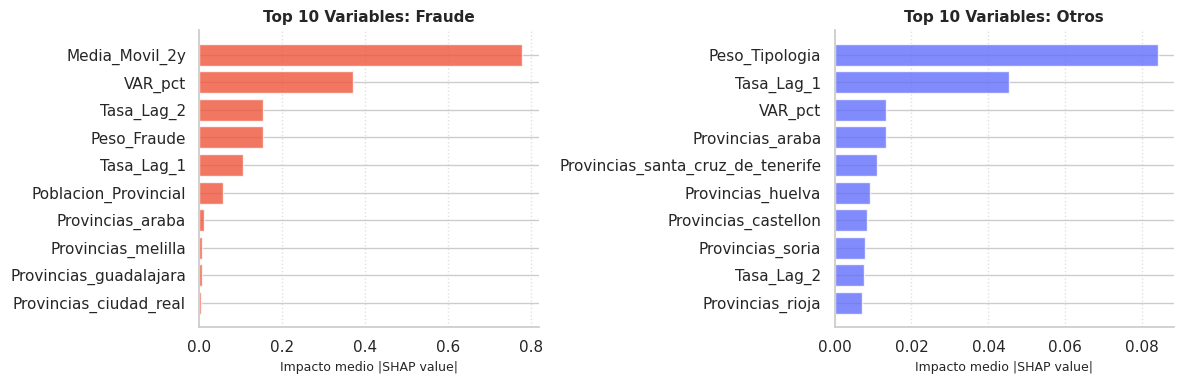

In [ ]:
# ==============================================================================
# @title VISUALIZACIÓN SHAP
# ==============================================================================
# Esta función genera dos gráficos SHAP en una sola fila:
# - Uno para el modelo de Fraude Informático
# - Otro para el modelo de Otros Ciberdelitos
#
# El objetivo es comparar visualmente las variables más influyentes
# en cada modelo.
# ==============================================================================

def shap_dos_columnas(pipe_f, pipe_o, df_f, df_o):

    # Crea una figura con 1 fila y 2 columnas (dos gráficos lado a lado)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ==========================================================================
    # 1. SHAP PARA FRAUDE INFORMÁTICO
    # ==========================================================================

    # Extrae el modelo final (RandomForest) y el preprocesador del pipeline
    model_f = pipe_f.named_steps['regressor']
    pre_f = pipe_f.named_steps['preprocessor']

    # Transforma los datos con el preprocesador (scaler + one-hot)
    Xf = pre_f.transform(df_f)
    if hasattr(Xf, "toarray"):  # Si es matriz dispersa, conviértela a densa
        Xf = Xf.toarray()
    Xf = Xf.astype(np.float32)

    # Obtiene los nombres de las columnas tras el preprocesado
    names_f = pre_f.get_feature_names_out()

    # Calcula los valores SHAP usando TreeExplainer (ideal para RandomForest)
    expl_f = shap.TreeExplainer(model_f)
    shap_f = expl_f.shap_values(Xf)
    if isinstance(shap_f, list):  # XGBoost/RandomForest pueden devolver lista
        shap_f = shap_f[0]

    # Importancia media absoluta de cada variable
    vals_f = np.abs(shap_f).mean(0)

    # Construye un DataFrame ordenado con las 10 variables más influyentes
    df_f_imp = pd.DataFrame({'columna': names_f, 'valor': vals_f})
    df_f_imp['columna'] = df_f_imp['columna'].apply(lambda x: x.split('__')[-1])
    df_f_imp = df_f_imp.sort_values(by='valor', ascending=False).head(10)

    # Gráfico horizontal para Fraude
    axes[0].barh(df_f_imp['columna'][::-1], df_f_imp['valor'][::-1],
                 color="#EF553B", alpha=0.8)
    axes[0].set_title("Top 10 Variables: Fraude", fontsize=11, fontweight='bold')
    axes[0].set_xlabel("Impacto medio |SHAP value|", fontsize=9)
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].grid(axis='x', linestyle=':', alpha=0.6)

    # ==========================================================================
    # 2. SHAP PARA OTROS CIBERDELITOS
    # ==========================================================================

    # Extrae modelo (XGBoost) y preprocesador
    model_o = pipe_o.named_steps['regressor']
    pre_o = pipe_o.named_steps['preprocessor']

    # Transforma los datos
    Xo = pre_o.transform(df_o)
    if hasattr(Xo, "toarray"):
        Xo = Xo.toarray()
    Xo = Xo.astype(np.float32)

    # Nombres de columnas tras preprocesado
    names_o = pre_o.get_feature_names_out()

    # Calcula SHAP
    expl_o = shap.TreeExplainer(model_o)
    shap_o = expl_o.shap_values(Xo)
    if isinstance(shap_o, list):
        shap_o = shap_o[0]

    # Importancia media absoluta
    vals_o = np.abs(shap_o).mean(0)

    # Top 10 variables
    df_o_imp = pd.DataFrame({'columna': names_o, 'valor': vals_o})
    df_o_imp['columna'] = df_o_imp['columna'].apply(lambda x: x.split('__')[-1])
    df_o_imp = df_o_imp.sort_values(by='valor', ascending=False).head(10)

    # Gráfico horizontal para Otros
    axes[1].barh(df_o_imp['columna'][::-1], df_o_imp['valor'][::-1],
                 color="#636EFA", alpha=0.8)
    axes[1].set_title("Top 10 Variables: Otros", fontsize=11, fontweight='bold')
    axes[1].set_xlabel("Impacto medio |SHAP value|", fontsize=9)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].grid(axis='x', linestyle=':', alpha=0.6)

    # Ajusta márgenes y muestra la figura final
    plt.tight_layout()
    plt.show()


# ==============================================================================
# EJECUCIÓN DE LA FUNCIÓN
# ==============================================================================

shap_dos_columnas(
    pipe_f,  # pipeline entrenado para Fraude
    pipe_o,  # pipeline entrenado para Otros
    df_ml_fraude.drop(columns=['Tasa_Criminalidad']),  # X fraude
    df_ml_otros.drop(columns=['Tasa_Criminalidad'])    # X otros
)

**Importancia media absoluta de las variables según SHAP para ambos modelos.**

Los resultados muestran qué predictores contribuyen de forma más consistente a las estimaciones:  
en **Fraude** predominan los **factores temporales** (media móvil, variaciones y retardos), mientras que en **Otros Ciberdelitos** destacan el **peso de la tipología** y la dinámica reciente de la serie.

In [ ]:
# ==============================================================================
# @title Guardado y Verificación de Modelos Finales (2025)
# ==============================================================================
#creo carpeta
os.makedirs("modelos_finales", exist_ok=True)

# Guardar los pipelines completos
joblib.dump(pipe_f, "modelos_finales/model_fraude_2025_optuna.joblib")
joblib.dump(pipe_o, "modelos_finales/model_otros_2025_optuna.joblib")

print("Modelos guardados correctamente en /modelos_finales/")

#Verificación de carga
pipe_cargado = joblib.load("modelos_finales/model_fraude_2025_optuna.joblib")
print("Verificación: Pipeline cargado con éxito.")

Modelos guardados correctamente en /modelos_finales/
Verificación: Pipeline cargado con éxito.


## Nota sobre el guardado de los modelos finales

Los modelos entrenados para 2025 se almacenan como pipelines completos, incluyendo tanto el preprocesamiento como el estimador optimizado. Esto garantiza que puedan reutilizarse en el futuro sin necesidad de reconstruir la ingeniería de variables ni repetir el entrenamiento. Tras el guardado, se realiza una verificación de carga para confirmar que los archivos se han generado correctamente y que los pipelines pueden emplearse directamente para nuevas predicciones.

## **Generación del dataset final de predicciones**

Este módulo construye el archivo oficial de predicciones para 2025 replicando la estructura exacta del dataset original de cibercrimen. Se integran las proyecciones del modelo, los metadatos del último año disponible (2024) y las métricas derivadas utilizadas en el análisis (peso, variación porcentual, total provincial). El resultado se exporta como CSV listo para su uso en GitHub y en la futura aplicación de Streamlit.

In [ ]:
# ==============================================================================
# @title Generación de CSV de Predicciones 2025
# ==============================================================================

def generar_csv_proyeccion_exacto(df_pred_f, df_pred_o, df_historico, anio_objetivo=2025):
    """
    Genera un DataFrame y un archivo CSV con las proyecciones,
    manteniendo la estructura exacta del dataset original de cibercrimen.
    """
    # 1. Unir las predicciones de fraude y otros delitos
    df_pred_full = pd.concat([df_pred_f, df_pred_o], ignore_index=True)

    # Asegurar el año correcto
    df_pred_full['periodo'] = anio_objetivo

    # 2. Renombrar columnas para alinear con el dataset original
    df_pred_full = df_pred_full.rename(columns={
        'Hechos_Predichos_2025': 'Total_Hechos',
        'Tasa_Predicha_2025': 'Tasa_Criminalidad'
    })

    # 3. Extraer metadatos estáticos del último año histórico (2024)
    # Esto nos permite cruzar y traer CCAA, codigo_ine y los hechos pasados
    df_previo = df_historico[df_historico['periodo'] == (anio_objetivo - 1)].copy()
    metadatos = df_previo[['Provincias', 'Grupo penal', 'CCAA', 'codigo_ine', 'Total_Hechos']].copy()
    metadatos = metadatos.rename(columns={'Total_Hechos': 'Total_Hechos_Anterior'})

    # 4. Hacer el cruce (merge)
    df_final = df_pred_full.merge(
        metadatos,
        on=['Provincias', 'Grupo penal'],
        how='left'
    )

    # 5. Calcular métricas derivadas agregadas igual que en el EDA
    # Total Provincial (suma de hechos por provincia en 2025)
    df_final['Total_Provincial'] = df_final.groupby('Provincias')['Total_Hechos'].transform('sum')

    # Peso Tipología (%)
    df_final['Peso_Tipologia'] = (df_final['Total_Hechos'] / df_final['Total_Provincial'] * 100).fillna(0)

    # Peso Fraude (%)
    df_final['Peso_Fraude'] = np.where(
        df_final['Grupo penal'] == 'fraude_informatico',
        df_final['Peso_Tipologia'],
        0.0
    )

    # Variación porcentual (VAR_pct) respecto al año anterior (2024)
    # Usamos replace(0, np.nan) para evitar errores matemáticos al dividir por cero
    df_final['VAR_pct'] = ((df_final['Total_Hechos'] - df_final['Total_Hechos_Anterior']) /
                           df_final['Total_Hechos_Anterior'].replace(0, np.nan) * 100)
    df_final['VAR_pct'] = df_final['VAR_pct'].fillna(0).round(2)

    # 6. Reordenar las columnas EXACTAMENTE como en df_cibercrimen.csv
    columnas_ordenadas = [
        'Provincias', 'Grupo penal', 'periodo', 'Total_Hechos',
        'Poblacion_Provincial', 'CCAA', 'Tasa_Criminalidad',
        'codigo_ine', 'Total_Provincial', 'Peso_Tipologia',
        'Peso_Fraude', 'VAR_pct'
    ]
    df_final = df_final[columnas_ordenadas]

    # 7. Exportar a CSV con el mismo formato (separador punto y coma)
    nombre_archivo = f"df_cibercrimen_predicciones_{anio_objetivo}.csv"
    df_final.to_csv(nombre_archivo, sep=';', index=False)

    return df_final

# --- EJECUCIÓN DEL REPORTE 2025 ---
# Utilizamos las variables correctas que ya existen en tu entorno
df_reporte_2025 = generar_csv_proyeccion_exacto(pred_fraude_2025, pred_otros_2025, df, 2025)

# Auditoría visual
print("\n--- SUMATORIO TOTAL 2025 SIN EXTRANJERO---")
print(f"Fraude Informático: {df_reporte_2025[df_reporte_2025['Grupo penal'] == 'fraude_informatico']['Total_Hechos'].sum():,.0f}")
print(f"Otros Ciberdelitos: {df_reporte_2025[df_reporte_2025['Grupo penal'] != 'fraude_informatico']['Total_Hechos'].sum():,.0f}")
print("\nVista previa de la estructura del dataset final:")
display(df_reporte_2025.head(3))
print("\nVista previa INFO:")
display(df_reporte_2025.info())


--- SUMATORIO TOTAL 2025 SIN EXTRANJERO---
Fraude Informático: 447,118
Otros Ciberdelitos: 56,694

Vista previa de la estructura del dataset final:


,Provincias,Grupo penal,periodo,Total_Hechos,Poblacion_Provincial,CCAA,Tasa_Criminalidad,codigo_ine,Total_Provincial,Peso_Tipologia,Peso_Fraude,VAR_pct
0,albacete,fraude_informatico,2025,3149.0,390751,Castilla-La Mancha,8.059906,2,3697.0,85.177171,85.177171,4.55
1,alicante,fraude_informatico,2025,16547.0,2033566,C. Valenciana,8.137023,3,19230.0,86.047842,86.047842,6.87
2,almeria,fraude_informatico,2025,5983.0,770554,Andalucía,7.765188,4,6817.0,87.765879,87.765879,14.49



Vista previa INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Provincias            416 non-null    object 
 1   Grupo penal           416 non-null    object 
 2   periodo               416 non-null    int64  
 3   Total_Hechos          416 non-null    float64
 4   Poblacion_Provincial  416 non-null    int64  
 5   CCAA                  416 non-null    object 
 6   Tasa_Criminalidad     416 non-null    float64
 7   codigo_ine            416 non-null    int64  
 8   Total_Provincial      416 non-null    float64
 9   Peso_Tipologia        416 non-null    float64
 10  Peso_Fraude           416 non-null    float64
 11  VAR_pct               416 non-null    float64
dtypes: float64(6), int64(3), object(3)
memory usage: 39.1+ KB


None

# **Nota técnica de validación proyección 2025 con datos oficiales SEC (2025)**

Las predicciones generadas por el modelo corresponden exclusivamente al **ámbito nacional provincial**, es decir, **no incluyen** las infracciones cometidas **en el extranjero**, ya que el dataset original utilizado para entrenar el modelo tampoco las incorpora.

Por este motivo, la comparación debe realizarse únicamente con el bloque **“Cibercriminalidad (infracciones penales cometidas en/por medio ciber)”** del ámbito nacional, excluyendo el apartado **“En el extranjero”** (pág. 507 del informe).

*Informe oficial:*  
[Balance de Criminalidad – Cuarto Trimestre 2025](https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/dam/jcr:7d3776cd-9ca4-4c02-8ca4-96b2571dbee4/Balance%20de%20Criminalidad%20Cuarto%20Trimestre%202025.pdf)

---

**Comparación de cifras: SEC 2025 vs. Predicción del modelo**

| Indicador            | SEC 2025 | Predicción 2025 |
|----------------------|----------|------------------|
| Total Cibercrimen    | 489.248  | 503.812          |
| Estafas informáticas | 430.493  | 447.118          |
| Otros ciberdelitos   | 58.755   | 56.694           |

---

**Porcentaje de acierto del modelo para el 2025**

| Categoría             | Oficial SEC | Predicción | Error Relativo | Acierto |
|-----------------------|-------------|------------|----------------|---------|
| Fraude Informático    | 430.493     | 447.118    | 3,86 %         | 96,1 %  |
| Otros Ciberdelitos    | 58.755      | 56.694     | 3,50 %         | 96,5 %  |
| Total Cibercrimen     | 489.248     | 503.812    | 2,97 %         | 97,0 %  |

---

**Conclusión**

- El modelo alcanza **más del 96 % de acierto** en ambas tipologías.  
- El acierto global en el total nacional es del **97 %**.  
- La ligera sobreestimación en fraude informático es coherente con la aceleración observada entre 2023 y 2024.  
- La predicción de “Otros ciberdelitos” se ajusta especialmente bien pese a su mayor volatilidad.  

En conjunto, el sistema reproduce con alta fidelidad la evolución real del cibercrimen en 2025, validando la solidez del pipeline y la calidad de la ingeniería de características.

In [ ]:
# ==============================================================================
# @title Ranking Top 5 Incrementos 2025 vs 2024 (Fraude y Otros Ciberdelitos)
# ==============================================================================

# 1. Cargar el dataset recién generado
df_2025 = pd.read_csv("df_cibercrimen_predicciones_2025.csv", sep=";")

# 2. Separar los dos flujos
df_fraude = df_2025[df_2025['Grupo penal'] == 'fraude_informatico'].copy()
df_otros = df_2025[df_2025['Grupo penal'] != 'fraude_informatico'].copy()

# 3. Generar Rankings (Ordenados por la variación porcentual de forma descendente)
# Seleccionamos las columnas clave para que la visualización sea limpia
cols_vista = ['Provincias', 'Grupo penal', 'Total_Hechos', 'Tasa_Criminalidad', 'VAR_pct']

top_10_fraude = df_fraude[cols_vista].sort_values(by='VAR_pct', ascending=False).head(5)
top_10_otros = df_otros[cols_vista].sort_values(by='VAR_pct', ascending=False).head(5)

# ==============================================================================
# Visualización de Tablas
# ==============================================================================
print("TOP 5 PROVINCIAS: MAYOR INCREMENTO EN FRAUDE INFORMÁTICO (2025 vs 2024)")
print("-" * 80)
# Aplicamos un estilo visual al DataFrame para destacar la variación en rojo
display(top_10_fraude.style.format({
    'Total_Hechos': '{:,.0f}',
    'Tasa_Criminalidad': '{:.2f}',
    'VAR_pct': '{:+.2f}%'
}).background_gradient(subset=['VAR_pct'], cmap='Reds'))

print("\n\nTOP 5 PROVINCIAS: MAYOR INCREMENTO EN OTROS CIBERDELITOS (2025 vs 2024)")
print("-" * 80)
display(top_10_otros.style.format({
    'Total_Hechos': '{:,.0f}',
    'Tasa_Criminalidad': '{:.2f}',
    'VAR_pct': '{:+.2f}%'
}).background_gradient(subset=['VAR_pct'], cmap='Oranges'))



TOP 5 PROVINCIAS: MAYOR INCREMENTO EN FRAUDE INFORMÁTICO (2025 vs 2024)
--------------------------------------------------------------------------------


,Provincias,Grupo penal,Total_Hechos,Tasa_Criminalidad,VAR_pct
41,santa_cruz_de_tenerife,fraude_informatico,"7,625",7.01,+19.83%
28,lleida,fraude_informatico,"4,675",10.20,+16.79%
14,castellon,fraude_informatico,"4,400",7.01,+16.34%
24,huelva,fraude_informatico,"3,626",6.73,+16.29%
10,burgos,fraude_informatico,"3,481",9.60,+16.03%




TOP 5 PROVINCIAS: MAYOR INCREMENTO EN OTROS CIBERDELITOS (2025 vs 2024)
--------------------------------------------------------------------------------


,Provincias,Grupo penal,Total_Hechos,Tasa_Criminalidad,VAR_pct
370,tarragona,contra_la_propiedad_industrial/intelectual,3,0.00,+200.00%
356,sevilla,contra_la_propiedad_industrial/intelectual,8,0.00,+100.00%
286,murcia,contra_la_propiedad_industrial/intelectual,12,0.01,+100.00%
398,valladolid,contra_la_propiedad_industrial/intelectual,2,0.00,+100.00%
265,madrid,contra_la_propiedad_industrial/intelectual,44,0.01,+91.30%


Este ranking permite identificar **dónde se prevé que los ciberdelitos aumenten con más intensidad en 2025**.

En **fraude informático**, los mayores incrementos corresponden a **provincias donde el fenómeno ya es estructural** y mantiene una tendencia ascendente.

En cambio, en los **otros ciberdelitos** aparecen subidas muy elevadas en tipologías minoritarias, donde variaciones pequeñas generan porcentajes altos.

En conjunto, el ranking muestra tanto los territorios con crecimiento real como los focos locales donde determinadas tipologías experimentan cambios más bruscos.

In [ ]:
# ==============================================================================
# RANKING: TIPOS DE "OTROS CIBERDELITOS" QUE MÁS CRECEN (2025 vs 2024)
# ==============================================================================

# Agrupar por tipología penal dentro del grupo "otros"
ranking_tipologias = (
    df_otros.groupby("Grupo penal")[["Total_Hechos", "VAR_pct"]]
    .mean()
    .sort_values("VAR_pct", ascending=False)
)

print("\nTOP TIPOS DE OTROS CIBERDELITOS QUE MÁS CRECEN (2025 vs 2024)")
print("-" * 80)
display(
    ranking_tipologias.style.format({
        "Total_Hechos": "{:,.0f}",
        "VAR_pct": "{:+.2f}%"
    }).background_gradient(subset=["VAR_pct"], cmap="Oranges")
)



TOP TIPOS DE OTROS CIBERDELITOS QUE MÁS CRECEN (2025 vs 2024)
--------------------------------------------------------------------------------


,Total_Hechos,VAR_pct
Grupo penal,,
acceso__e_interceptacion_ilicita,222,+16.20%
falsificacion_informatica,429,+14.74%
interferencia_en_los_datos_y_en_el_sistema,39,+3.83%
amenazas_y_coacciones,341,+1.82%
contra_el_honor,22,+1.17%
contra_la_propiedad_industrial/intelectual,6,+0.81%
delitos_sexuales,32,-1.03%


Este ranking muestra **qué tipologías dentro de “otros ciberdelitos” son las que más aumentan en 2025**. Los mayores crecimientos se concentran en delitos vinculados al acceso ilegal, la falsificación y la interferencia en sistemas, que son los que muestran una dinámica más activa. Otras tipologías, como amenazas, contra el honor o los delitos sexuales online, presentan incrementos moderados o incluso ligeros descensos, lo que indica un comportamiento más estable y menos expansivo dentro del conjunto.

In [ ]:
# ==============================================================================
# TOP PROVINCIAS DONDE MÁS CRECE CADA TIPO DE "OTROS CIBERDELITOS"
# ==============================================================================

# Agrupamos por tipología y provincia
ranking_tipologia_provincia = (
    df_otros.groupby(["Grupo penal", "Provincias"])[["Total_Hechos", "VAR_pct"]]
    .mean()
    .sort_values("VAR_pct", ascending=False)
)

print("\nTOP PROVINCIAS POR TIPOS DE OTROS CIBERDELITOS (2025 vs 2024)")
print("-" * 80)

# Mostramos los 10 mayores incrementos combinados
display(
    ranking_tipologia_provincia.head(10).style.format({
        "Total_Hechos": "{:,.0f}",
        "VAR_pct": "{:+.2f}%"
    }).background_gradient(subset=["VAR_pct"], cmap="Oranges")
)



TOP PROVINCIAS POR TIPOS DE OTROS CIBERDELITOS (2025 vs 2024)
--------------------------------------------------------------------------------


Este ranking muestra **qué provincias registran los mayores aumentos dentro de cada tipología de “otros ciberdelitos”**. Los porcentajes más altos aparecen en delitos con muy pocos casos, por lo que reflejan **cambios puntuales**, no tendencias generales. Aun así, permiten localizar **focos concretos** donde ciertas tipologías muestran variaciones más intensas.

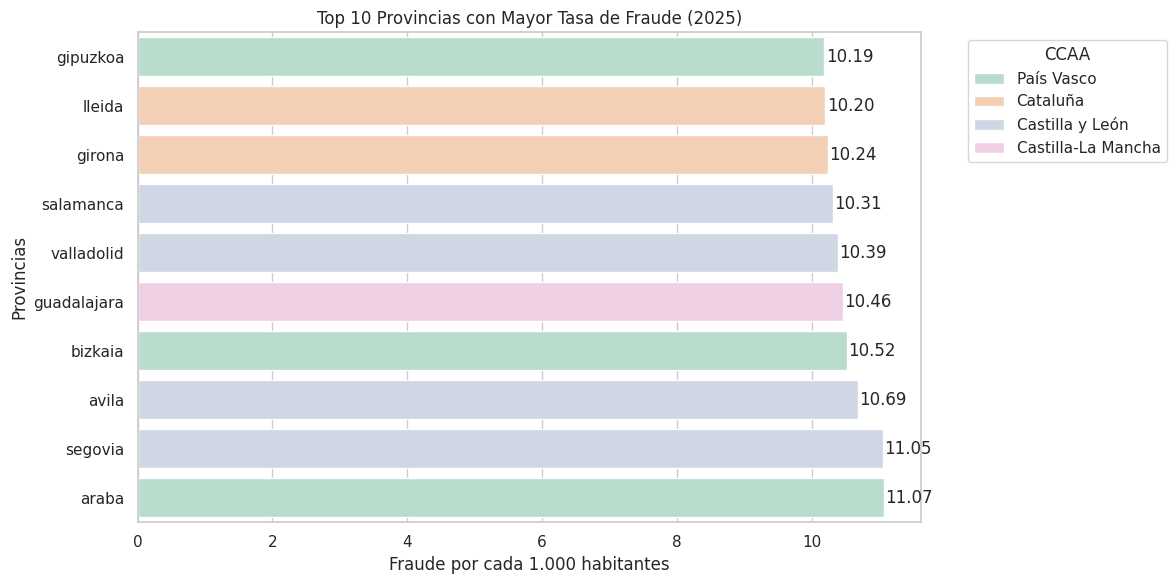

In [ ]:
# ==============================================================================
# Top 10 Provincias con Mayor Tasa de Fraude (2025)
# ==============================================================================

# 1. Filtrar solo fraude informático
df_fraude_2025 = df_2025[df_2025["Grupo penal"] == "fraude_informatico"].copy()

# 2. Top 10 por tasa en 2025
top10_fraude_2025 = (
    df_fraude_2025
    .nlargest(10, "Tasa_Criminalidad")
    .sort_values("Tasa_Criminalidad", ascending=True)
)

# 3. Estilo
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))

# 4. Gráfico horizontal
ax = sns.barplot(
    data=top10_fraude_2025,
    x="Tasa_Criminalidad",
    y="Provincias",
    hue="CCAA",
    palette="Pastel2",
    dodge=False
)

# 5. Etiquetas numéricas
for i, v in enumerate(top10_fraude_2025["Tasa_Criminalidad"]):
    plt.text(v + 0.02, i, f"{v:.2f}", va="center")

# 6. Títulos y ajustes
plt.title("Top 10 Provincias con Mayor Tasa de Fraude (2025)", fontsize=12)
plt.xlabel("Fraude por cada 1.000 habitantes")
plt.ylabel("Provincias")
plt.legend(title="CCAA", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


**Pie de gráfico:**  
*El patrón territorial del fraude se mantiene estable: las provincias con mayor tasa en 2024 siguen destacando en 2025.*

# **RESUMEN EJECUTIVO 2025**

En 2025 se prevén **503.812 ciberdelitos** en España (sin extranjero) distribuidos de la siguiente forma:

- **Fraude informático:** 447.118 casos  
- **Otros ciberdelitos:** 56.694 casos  

El fraude sigue siendo el fenómeno dominante y **crece de forma generalizada** en casi todas las provincias, con picos en **Santa Cruz de Tenerife, Castellón, Huelva, Lleida y Granada**.

Dentro de *otros ciberdelitos*, las tipologías que más aumentan son:

- **Acceso e interceptación ilícita**  
- **Falsificación informática**  
- **Interferencia en datos/sistemas**

El crecimiento es **muy desigual por provincia**, con incrementos altos en lugares concretos debido al bajo volumen previo (por eso aparecen porcentajes muy elevados en tipologías minoritarias).

En conjunto, el modelo anticipa:

- **Un aumento sostenido del fraude**, homogéneo y estable.  
- **Un crecimiento irregular del resto de tipologías**, con focos locales y variabilidad alta.


- La estructura agregada en **8 grupos penales** permite una lectura más clara del fenómeno y mejora la capacidad predictiva del modelo.

---

# **Tabla resumen de los 8 grupos penales y delitos incluidos**

| **Grupo penal** | **Delitos incluidos (resumen)** |
|-----------------|----------------------------------|
| **Fraude informático** | Estafas bancarias, estafas informáticas, estafas con tarjetas, estafas de inversores, otras estafas. |
| **Acceso e interceptación ilícita** | Acceso ilegal a sistemas, revelación de secretos, intrusismo, interceptación de datos, facilitación de claves o programas para ataques. |
| **Falsificación informática** | Usurpación de identidad, falsificación de documentos, tarjetas, DNI/pasaporte, moneda, útiles para falsificar. |
| **Interferencia en datos y sistemas** | Ataques a datos, programas o sistemas informáticos; daños informáticos. |
| **Amenazas y coacciones** | Amenazas, extorsión, coacciones, acoso, trato degradante, amenazas a colectivos. |
| **Delitos sexuales online** | Sexting, grooming, pornografía de menores, abusos/agresiones sexuales, exhibicionismo, prostitución. |
| **Contra el honor** | Injurias, calumnias, perfiles falsos para acoso, difusión pública de contenidos ofensivos. |
| **Propiedad industrial/intelectual** | Piratería, espionaje industrial, acceso fraudulento a servicios, delitos contra consumidores. |

---


# **1. Implicaciones para 2026**
El comportamiento proyectado para 2025 sugiere que 2026 podría mantener la tendencia alcista del fraude, mientras que los delitos técnicos seguirán mostrando variabilidad territorial y sensibilidad a eventos locales.

**2. Nota metodológica**
Las predicciones se basan en modelos RandomForest y XGBoost optimizados mediante validación temporal y evaluados con WAPE como métrica principal, garantizando estabilidad en tipologías con valores bajos o dispersos.

**3. Cierre institucional**
Este modelo permite anticipar cargas operativas, priorizar recursos y mejorar la planificación estratégica en materia de ciberseguridad, proporcionando una base cuantitativa sólida para la toma de decisiones.